In [164]:
import numpy as np
import mne
from pathlib import Path

import matplotlib.pyplot as plt

from scipy.signal import resample_poly, find_peaks, welch
from scipy.stats import gaussian_kde

In [165]:
dataset_path = Path("BCI4_2a")
subject_id = 3

In [166]:
def read_subject_epochs(subject_id: int|list, dataset_path: Path,
                        is_train: bool = True,
                        l_freq: float = 4.0,
                        h_freq: float = 37.0,
                        tmin: float = -0.5,
                        tmax: float = 4.5):
    """
    Загружает EEG одного субъекта BCI IV 2a и возвращает:
    epochs, X, y, label_names
    """
    train_eval_label = "T" if is_train else "E"

    if type(subject_id) == int:
        subject_prefix = f"A0{subject_id}"
        subject_training_data_path = dataset_path / (subject_prefix + f"{train_eval_label}.gdf")
        raw = mne.io.read_raw_gdf(subject_training_data_path, preload=True)
    else:
        raw = []
        for i in subject_id:
            subject_prefix = f"A0{i}"
            subject_training_data_path = dataset_path / (subject_prefix + f"{train_eval_label}.gdf")
            raw.append(mne.io.read_raw_gdf(subject_training_data_path, preload=True))
        raw = mne.concatenate_raws(raw)
    bci_channels = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2',
    'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz'
    ]

    # Создаем соответствие с индексами каналов в данных
    # (если каналы называются иначе)
    if raw.ch_names[0].startswith('EEG'):
        rename_dict = dict()
        for key, value in zip(raw.ch_names[:-3], bci_channels):
            rename_dict[key] = value
        raw.rename_channels(rename_dict)
    raw.filter(l_freq, h_freq, verbose=False)
    raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])

    raw.set_montage('standard_1020')

    events, event_dict = mne.events_from_annotations(raw)

    event_id = {
        "left": event_dict["769"],
        "right": event_dict["770"],
        "foot": event_dict["771"],
        "tongue": event_dict["772"],
    }

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose=False
    )

    X = epochs.get_data()  # (n_epochs, n_channels, n_times)
    y_raw = epochs.events[:, -1]

    label_map = {
        event_dict["769"]: 0,
        event_dict["770"]: 1,
        event_dict["771"]: 2,
        event_dict["772"]: 3,
    }
    inv_label_map = {0: "left", 1: "right", 2: "foot", 3: "tongue"}

    y = np.array([label_map[i] for i in y_raw])

    return epochs, X, y, inv_label_map

In [167]:
epochs, X, y, inv_label_map = read_subject_epochs(subject_id, dataset_path, l_freq=6, h_freq=14)

Extracting GDF parameters from BCI4_2a/A03T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 660529  =      0.000 ...  2642.116 secs...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


In [168]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from scipy.stats import pearsonr

def compute_correlation_matrix(epochs, method='pearson'):
    """
    Вычисляет корреляционную матрицу между каналами для набора эпох.
    
    Параметры
    ---------
    epochs : mne.Epochs
        Объект с эпохами (один субъект или объединённые данные).
    method : str, optional
        Метод корреляции: 'pearson' (по умолчанию) или 'spearman'.
    
    Возвращает
    ----------
    corr_mat : np.ndarray, shape (n_channels, n_channels)
        Корреляционная матрица.
    ch_names : list
        Список имён каналов.
    """
    # Извлекаем данные: (n_epochs, n_channels, n_times)
    data = epochs.get_data()
    n_epochs, n_channels, n_times = data.shape
    
    # Объединяем все эпохи по временной оси -> (n_channels, n_epochs * n_times)
    data_concat = data.transpose(1, 0, 2).reshape(n_channels, -1)
    
    # Вычисляем корреляцию
    if method == 'pearson':
        corr_mat = np.corrcoef(data_concat)
    elif method == 'spearman':
        from scipy.stats import spearmanr
        corr_mat, _ = spearmanr(data_concat.T)  # spearmanr ожидает (samples, variables)
    else:
        raise ValueError("method должен быть 'pearson' или 'spearman'")
    
    ch_names = epochs.ch_names
    return corr_mat, ch_names

def plot_correlation_matrix(corr_mat, ch_names, title='Correlation matrix', save_path=None):
    """
    Визуализирует корреляционную матрицу с помощью seaborn.
    """
    plt.figure(figsize=(10, 8))
    mask = np.ones_like(corr_mat, dtype=bool) # маска для верхнего треугольника
    sns.heatmap(corr_mat, 
    #mask=mask, 
    cmap='RdBu_r', center=0, 
                square=True, xticklabels=ch_names, yticklabels=ch_names,
                cbar_kws={'label': 'Correlation coefficient'})
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

In [169]:
comp_left = compute_correlation_matrix(epochs['left'], method='spearman')
comp_right = compute_correlation_matrix(epochs['foot'], method='spearman')

In [170]:
comp_left[0].min()

np.float64(0.3679217926932051)

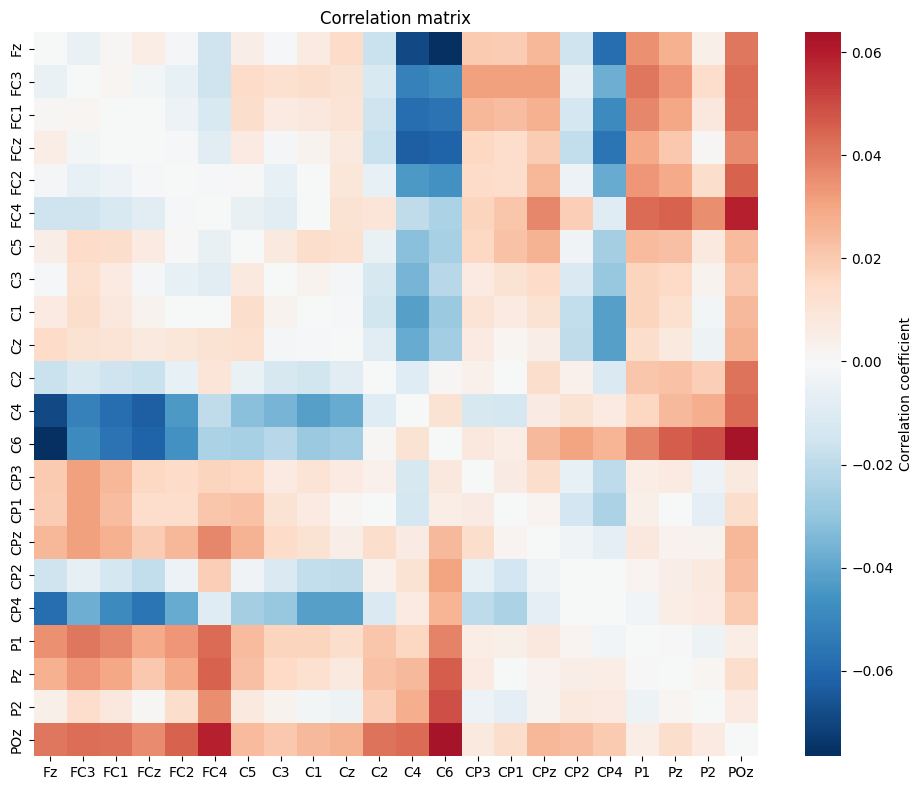

In [171]:
ch_names = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2',
    'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz'
    ]
plot_correlation_matrix(comp_right[0]-comp_left[0], ch_names)

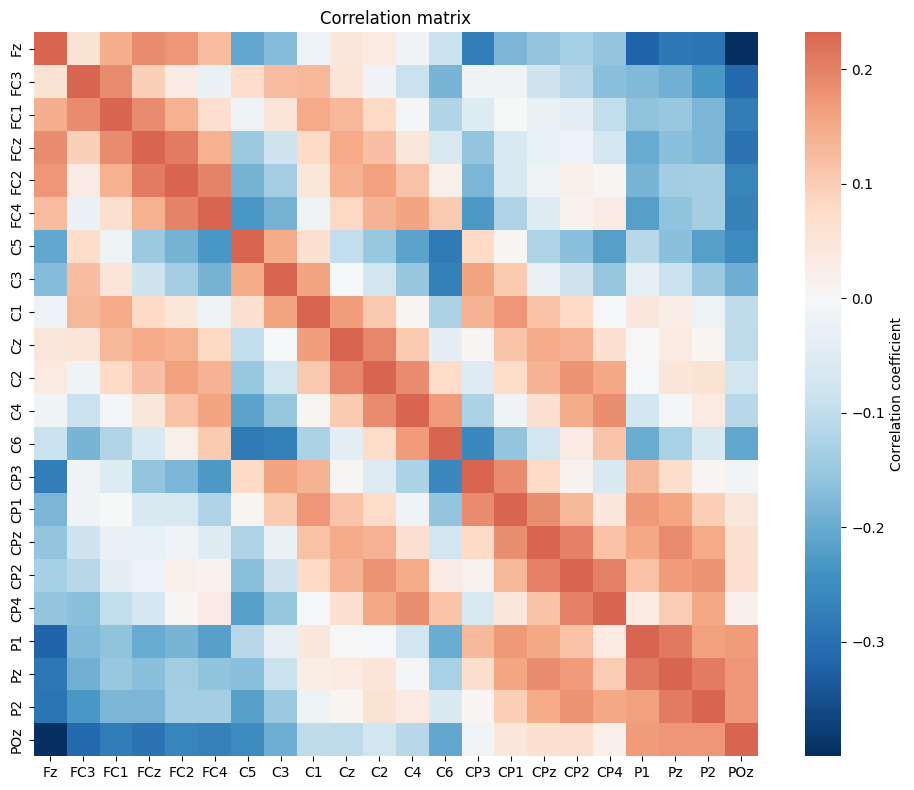

In [172]:
plot_correlation_matrix(comp_left[0] - np.mean(comp_left[0]), ch_names)

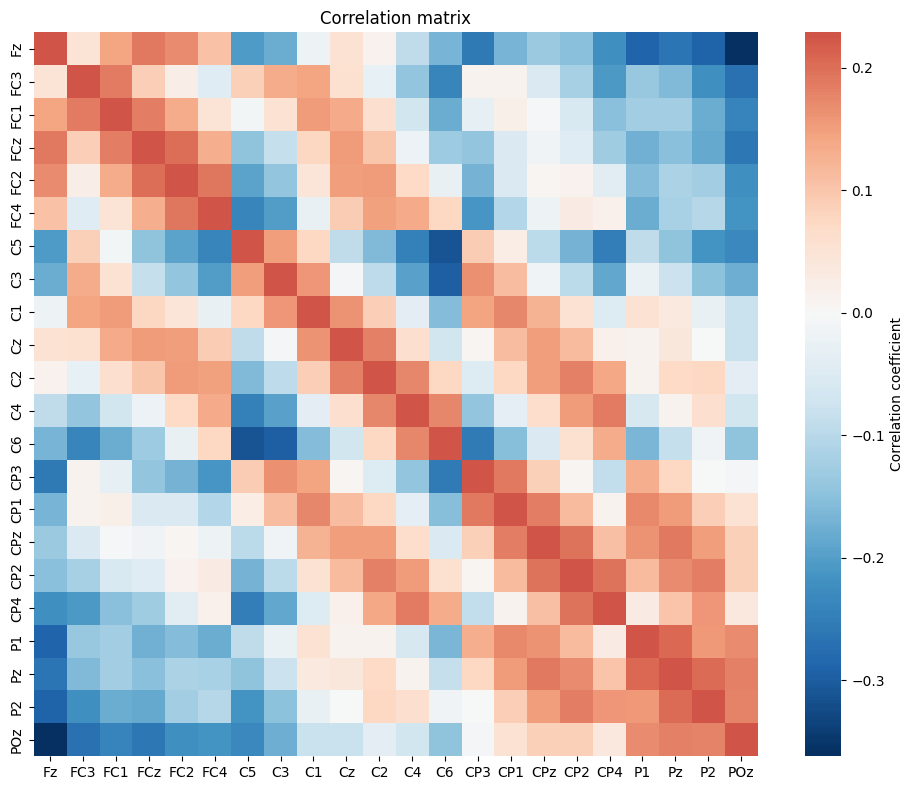

In [173]:
plot_correlation_matrix(comp_right[0] - np.mean(comp_right[0]), ch_names)